In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
df = pd.read_csv('./datasets/iris.csv')
print(df.shape)
print(df.isnull().sum())
df.head()

(150, 6)
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


<Axes: xlabel='Species', ylabel='count'>

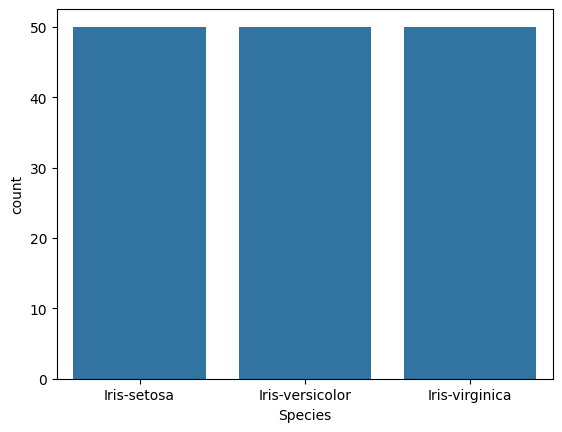

In [4]:
sns.countplot(x='Species', data=df)

In [5]:
x = df.drop(columns='Species').values
y = df['Species'].values

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [6]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [7]:
accuracies = []
k_range = range(3, 21)  # 1 may be overfitted

for k in k_range:
  knn = KNeighborsClassifier(n_neighbors=k)
  knn.fit(x_train, y_train)
  accuracies.append(accuracy_score(y_test, knn.predict(x_test)))

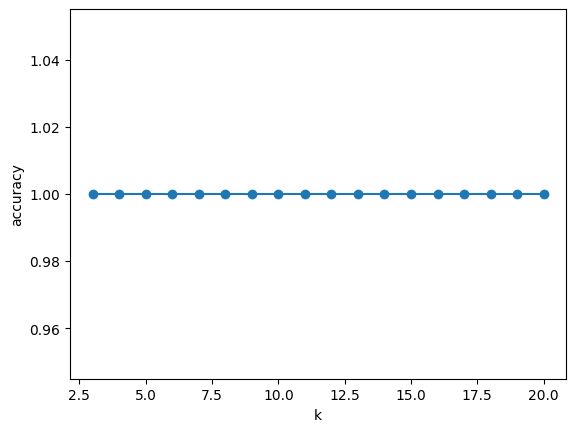

In [8]:
plt.plot(k_range, accuracies, marker='o')
plt.xlabel('k')
plt.ylabel('accuracy')
plt.show()

In [9]:
best_k = k_range[accuracies.index(max(accuracies))]
best_k

3

In [10]:
model = KNeighborsClassifier(n_neighbors=best_k)
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

accuracy_score(y_test, y_pred)

1.0

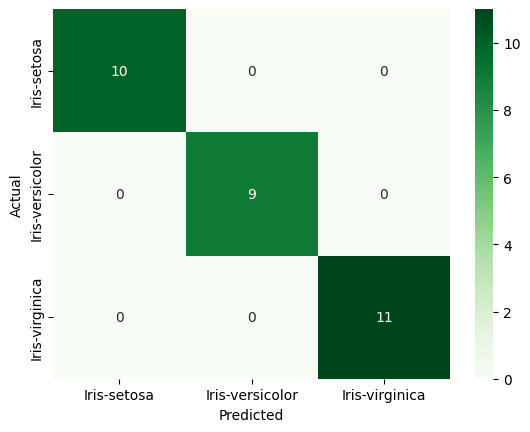

In [11]:
species = df['Species'].unique()

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=species, yticklabels=species)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [12]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [14]:
sepal_length = 4.8
sepal_width  = 3.3
petal_length = 1.5
petal_width  = 0.3

sample = np.array([[0, sepal_length, sepal_width, petal_length, petal_width]])  # Id 자리는 0
sample_scaled = scaler.transform(sample)

prediction = model.predict(sample_scaled)
print("예측 결과:", prediction[0])

예측 결과: Iris-setosa
